In [1]:
import itertools
import pickle
import numpy as np
from compute_RSA import calculate_RSA
import matplotlib.pyplot as plt
from plot_RSA_layers import filter_rsa_data
import matplotlib.patheffects as path_effects

ROIList = ["V1", "pFS", "LO", "EBA", "MTSTS", "infIPS", "SMG", "behavior"]
MRI_RDMs = np.zeros((15, len(ROIList), 6, 6))

nsub = 0
for sub in range(2, 18):
    if sub == 8:
        continue
    subject = f"S{sub:02d}"

    for r, region in enumerate(ROIList):
        RDM_folder = f"result/fMRI RDM/pearson/{region}"
        if region == "behavior":
            with open(f"{RDM_folder}/RDM_dynamic.pkl", "rb") as File:
                dynamic_RDM = pickle.load(File)
        else:
            with open(
                f"{RDM_folder}/{subject}_RDM_all_dynamic.pkl", "rb"
            ) as File:
                dynamic_RDM = pickle.load(File)
                
        MRI_RDMs[nsub, r, :, :] = dynamic_RDM
    nsub += 1
        
MRI_RSA = np.ones((15, len(ROIList), len(ROIList)))
combinations = list(itertools.combinations(range(len(ROIList)), 2))
for s in range(15):
    for c1, c2 in combinations:
        RSA, _ = calculate_RSA(MRI_RDMs[s, c1, :, :], MRI_RDMs[s, c2, :, :])
        MRI_RSA[s, c1, c2] = MRI_RSA[s, c2, c1] = RSA
    
MRI_RSA = np.mean(MRI_RSA, axis=0)

In [2]:
condition = ["SF-S", "SF-F", "SF-S-noF", "S-only"]
dataset = ["k400"]

model_RDMs = np.zeros((len(condition), 6, 6))

for c, cond in enumerate(condition):
    
    if cond in ["SF-S", "SF-F"]:
        model_name = "slowfast_r50"
    elif cond == "SF-S-noF":
        model_name = "slow_r50"
    else:
        model_name = "res_r50"
        
    model_path = f"result/model RDM/dynamic/pearson_RDM_{model_name}.pkl"
    with open(model_path, "rb") as pickle_file:
        model_RDM = pickle.load(pickle_file)
        
    filtered_list = filter_rsa_data(model_RDM, cond)
    indices = [i for i, key in enumerate(model_RDM.keys()) if key in filtered_list]
    
    model_RDM = np.array(list(model_RDM.values()))
    model_RDM = model_RDM[indices, :, :]
    model_RDM = model_RDM[11, :, :]
    
    model_RDMs[c, :, :] = model_RDM

model_RSA = np.ones((len(condition), len(condition)))
combinations = list(itertools.combinations(range(len(condition)), 2))
for c1, c2 in combinations:
    RSA, _ = calculate_RSA(model_RDMs[c1, :, :], model_RDMs[c2, :, :])
    model_RSA[c1, c2] = model_RSA[c2, c1] = RSA

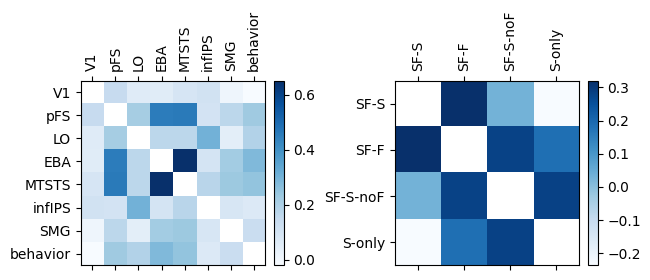

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(6.4, 4.8*2), constrained_layout=True)

np.fill_diagonal(MRI_RSA, np.nan)
np.fill_diagonal(model_RSA, np.nan)

cax = axes[0].matshow(MRI_RSA, cmap="Blues")
axes[0].set_xticks(np.arange(len(ROIList)))
axes[0].set_yticks(np.arange(len(ROIList)))
axes[0].set_xticklabels(ROIList, rotation=90)
axes[0].set_yticklabels(ROIList)
fig.colorbar(cax, ax=axes[0], fraction=0.05)


cax = axes[1].matshow(model_RSA, cmap="Blues")
axes[1].set_xticks(np.arange(len(condition)))
axes[1].set_yticks(np.arange(len(condition)))
axes[1].set_xticklabels(condition, rotation=90)
axes[1].set_yticklabels(condition)
fig.colorbar(cax, ax=axes[1], fraction=0.05)
plt.show()

MRI Stress: 0.9696285771475949
Model Stress: 0.013010426616022176


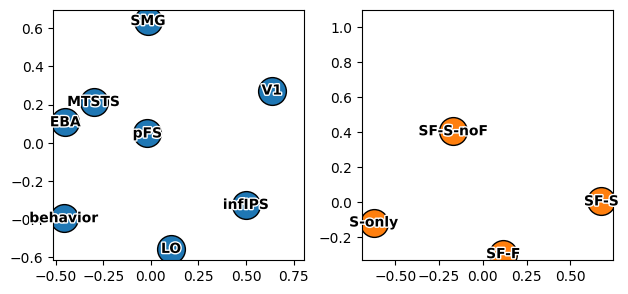

In [5]:
from sklearn.manifold import MDS

seed = np.random.RandomState(seed=1)
mds = MDS(dissimilarity='precomputed', n_components=2, random_state=seed, eps=1e-15)
mds_R1 = mds.fit_transform(1 - MRI_RSA)

print(f"MRI Stress: {mds.stress_}")

seed = np.random.RandomState(seed=0)
mds = MDS(dissimilarity='precomputed', n_components=2, random_state=seed, eps=1e-15)
mds_R = mds.fit_transform(1 - model_RSA)

print(f"Model Stress: {mds.stress_}")

fig, axes = plt.subplots(1, 2, figsize=(6.4, 4.8*2))

scatter = axes[0].scatter(mds_R1[:, 0], mds_R1[:, 1], s=400, edgecolors="black", c="tab:blue")

for i, txt in enumerate(ROIList):
    text = axes[0].text(mds_R1[i, 0], mds_R1[i, 1], txt, ha="center", va="center", fontweight="bold")
    text.set_path_effects([path_effects.Stroke(linewidth=2, foreground="white"), path_effects.Normal()])

# axes[0].xaxis.set_visible(False)
# axes[0].yaxis.set_visible(False)
axes[0].axis("square")

scatter = axes[1].scatter(mds_R[:, 0], mds_R[:, 1], s=400, edgecolors="black", c="tab:orange")

for i, txt in enumerate(condition):
    text = axes[1].text(mds_R[i, 0], mds_R[i, 1], txt, ha="center", va="center", fontweight="bold")
    text.set_path_effects([path_effects.Stroke(linewidth=2, foreground="white"), path_effects.Normal()])

# axes[1].xaxis.set_visible(False)
# axes[1].yaxis.set_visible(False)
axes[1].axis("square")

plt.tight_layout()
plt.show()

In [3]:
model_RDMs = np.repeat(model_RDMs[np.newaxis, :, :, :], 15, axis=0)
RDMs = np.concatenate((MRI_RDMs, model_RDMs), axis=1)
whole_RSA = np.ones((15, len(ROIList)+len(condition), len(ROIList)+len(condition)))
combinations = list(itertools.combinations(range(len(ROIList)+len(condition)), 2))
for s in range(15):
    for c1, c2 in combinations:
        RSA, _ = calculate_RSA(RDMs[s, c1, :, :], RDMs[s, c2, :, :])
        whole_RSA[s, c1, c2] = whole_RSA[s, c2, c1] = RSA
    
whole_RSA = np.mean(whole_RSA, axis=0)

Stress: 3.230593187994378


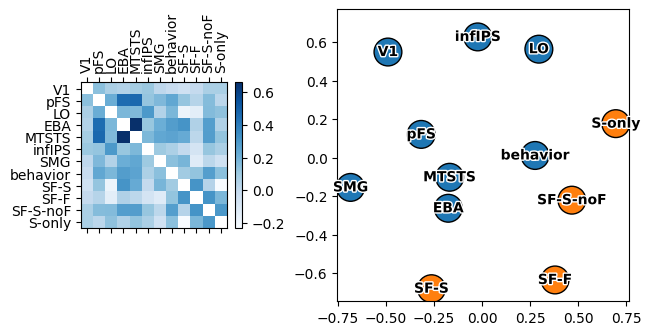

In [ ]:
seed = np.random.RandomState(seed=9)
mds = MDS(dissimilarity='precomputed', n_components=2, random_state=seed, eps=1e-15)
mds_R = mds.fit_transform(1 - whole_RSA)

print(f"Stress: {mds.stress_}")

# Adjust figure size and remove extra spacing
fig, axes = plt.subplots(1, 2, figsize=(6.4, 4.8*2), constrained_layout=True, gridspec_kw={'width_ratios': [1, 2]})

np.fill_diagonal(whole_RSA, np.nan)
# First plot (matshow)
cax = axes[0].matshow(whole_RSA, cmap="Blues")
axes[0].set_xticks(np.arange(len(ROIList + condition)))
axes[0].set_yticks(np.arange(len(ROIList + condition)))
axes[0].set_xticklabels(ROIList + condition, rotation=90)
axes[0].set_yticklabels(ROIList + condition)

# Adjust colorbar padding
fig.colorbar(cax, ax=axes[0], fraction=0.05)

# Second plot (scatter)
colors = ["tab:blue"] * 8 + ["tab:orange"] * 4
scatter = axes[1].scatter(mds_R[:, 0], mds_R[:, 1], s=400, edgecolors="black", c=colors)

for i, txt in enumerate(ROIList + condition):
    text = axes[1].text(mds_R[i, 0], mds_R[i, 1], txt, ha="center", va="center", fontweight="bold")
    text.set_path_effects([path_effects.Stroke(linewidth=2, foreground="white"),
                            path_effects.Normal()])

# axes[1].xaxis.set_visible(False)
# axes[1].yaxis.set_visible(False)
axes[1].axis("square")

plt.show()

In [35]:
condition = ["SF-S", "SF-F", "SF-S-noF", "S-only"]
dataset = ["k400"]

model_RDMs = np.zeros((len(condition), 17, 6, 6))

for c, cond in enumerate(condition):
    
    if cond in ["SF-S", "SF-F"]:
        model_name = "slowfast_r50"
    elif cond == "SF-S-noF":
        model_name = "slow_r50"
    else:
        model_name = "res_r50"
        
    model_path = f"result/model RDM/dynamic/pearson_RDM_{model_name}.pkl"
    with open(model_path, "rb") as pickle_file:
        model_RDM = pickle.load(pickle_file)
        
    filtered_list = filter_rsa_data(model_RDM, cond)
    indices = [i for i, key in enumerate(model_RDM.keys()) if key in filtered_list]
    
    model_RDM = np.array(list(model_RDM.values()))
    model_RDM = model_RDM[indices, :, :]
    
    model_RDMs[c, :, :, :] = model_RDM

combinations = list(itertools.combinations(range(len(condition)), 2))
model_RSA = np.zeros((len(combinations), 17, 17))

for c, (c1, c2) in enumerate(combinations):
    for l1 in range(17):
        for l2 in range(17):
            RSA, _ = calculate_RSA(model_RDMs[c1, l1, :, :], model_RDMs[c2, l2, :, :])
            model_RSA[c, l1, l2] = RSA

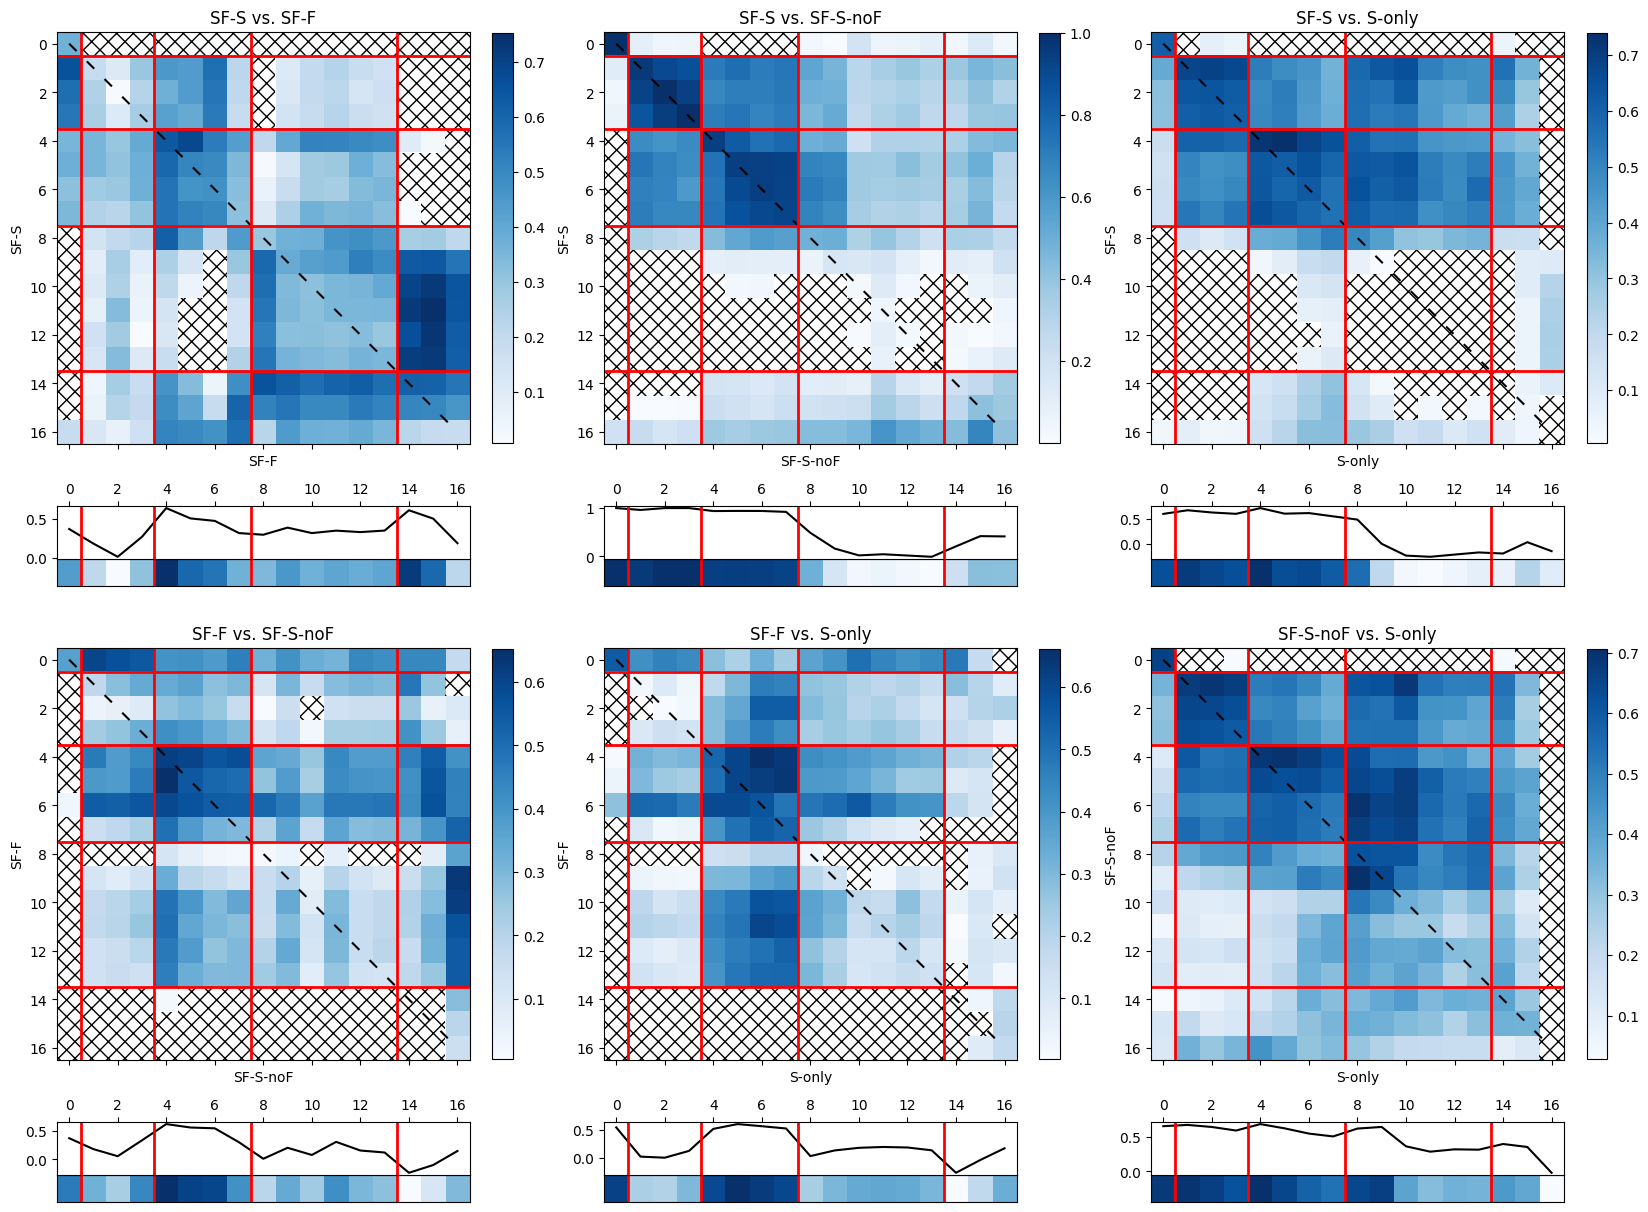

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(6, 3, height_ratios=[10, 1, 0.5, 10, 1, 0.5], hspace=0)
axes_diag = []

for c, (c1, c2) in enumerate(combinations):
    row = (c // 3) * 3
    col = c % 3
    
    ax = plt.subplot(gs[row, col])
    
    masked_data = np.ma.masked_less(model_RSA[c, :, :], 0)
    cax = ax.matshow(masked_data, cmap="Blues")
    
    for i in range(model_RSA[c, :, :].shape[0]):
        for j in range(model_RSA[c, :, :].shape[1]):
            if model_RSA[c, i, j] < 0:
                rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1, hatch="xx", fill=False, linewidth=0)
                ax.add_patch(rect)

    ax.set_xlabel(condition[c2])
    ax.set_ylabel(condition[c1])
    ax.set_title(f"{condition[c1]} vs. {condition[c2]}")
    fig.colorbar(cax, ax=ax, fraction=0.045)
    size = model_RSA.shape[1]
    ax.plot(range(size), range(size), color='black', ls=(0, (5, 7)))
        
    ax.xaxis.set_tick_params(labeltop=False, top=False)

    ax2 = plt.subplot(gs[row + 2, col], sharex=ax)
    diag_values = np.diag(model_RSA[c, :, :]).reshape(1, -1)
    im = ax2.imshow(diag_values, cmap="Blues", aspect="auto")
    ax2.xaxis.set_tick_params(labelbottom=False, bottom=False)
    ax2.set_yticks([])
    
    ax3 = plt.subplot(gs[row + 1, col], sharex=ax)
    ax3.plot(diag_values.T, color='black')

    ax3.xaxis.set_tick_params(labeltop=True, labelbottom=False, top=True, bottom=False)
    
    for fusion in [1, 4, 8, 14]:
        ax.axhline(y=fusion - 0.5, color='red', linewidth=2)
        ax.axvline(x=fusion - 0.5, color='red', linewidth=2)
        ax2.axvline(x=fusion - 0.5, color='red', linewidth=2)
        ax3.axvline(x=fusion - 0.5, color='red', linewidth=2)
    
    pos = ax.get_position()
    pos2 = ax2.get_position()
    pos3 = ax3.get_position()
    ax2.set_position([pos.x0,pos2.y0,pos.width,pos2.height])
    ax3.set_position([pos.x0,pos3.y0,pos.width,pos3.height])

plt.show()

In [23]:
model_path = "result/model RDM/dynamic/pearson_RDM_slowfast_r50.pkl"
with open(model_path, "rb") as pickle_file:
    model_RDM = pickle.load(pickle_file)

slow = [i for i, key in enumerate(model_RDM.keys()) if key in filter_rsa_data(model_RDM, "SF-S")]
fusion = [i for i, key in enumerate(model_RDM.keys()) if key in filter_rsa_data(model_RDM, "fusion")]

indices = np.searchsorted(slow, fusion, side='left')
print(indices)

[ 1  4  8 14]


# Behavioral Data

In [98]:
import scipy

data = scipy.io.loadmat('O1O.mat')

In [99]:
count_matrix = data['count_matrix']
data = data['data']

In [87]:
names = [
"reptile",
"ball",
"reptile",
"ball",
"ball",
"ball",
"reptile",
"quadruped_mammal",
"reptile",
"PS",
"PS",
"ball",
"quadruped_mammal",
"ball",
"human",
"tool",
"quadruped_mammal",
"PS",
"PS",
"human",
"quadruped_mammal",
"PS",
"quadruped_mammal",
"human",
"human",
"reptile",
"quadruped_mammal",
"PS",
"reptile",
"human",
"human",
"tool",
"tool",
"tool",
"tool",
"tool"
]

In [100]:
n= np.array(names)
ind = np.argsort(n)
np.sort(n)

array(['PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'ball', 'ball', 'ball', 'ball',
       'ball', 'ball', 'human', 'human', 'human', 'human', 'human',
       'human', 'quadruped_mammal', 'quadruped_mammal',
       'quadruped_mammal', 'quadruped_mammal', 'quadruped_mammal',
       'quadruped_mammal', 'reptile', 'reptile', 'reptile', 'reptile',
       'reptile', 'reptile', 'tool', 'tool', 'tool', 'tool', 'tool',
       'tool'], dtype='<U16')

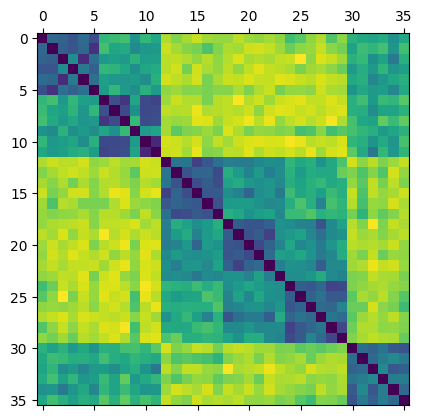

In [101]:
data = data / (count_matrix + np.eye(36))

data = data[ind, :]
data = data[:, ind]

import matplotlib.pyplot as plt

plt.matshow(data)

In [ ]:
num_splits = 1000
N = 353
correlations = []

for i in range(num_splits):
    idx = np.random.permutation(N)
    half1, half2 = idx[:N//2], idx[N//2:]

    BDM_A = compute_dissimilarity_matrix(half1)
    BDM_B = compute_dissimilarity_matrix(half2)

    corr = np.corrcoef(BDM_A.flatten(), BDM_B.flatten())[0,1]
    correlations.append(corr)

std_dev = np.std(correlations)